In [58]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole # might not be needed?

from rdkit.Chem.Draw import rdMolDraw2D

from IPython.display import SVG
from IPython.display import Image

import pandas as pd

Get an InChI string to work with:

In [2]:
df_train_labels = pd.read_csv("../data/train_labels.csv", nrows=1)
inchi = df_train_labels.iloc[0]['InChI']
inchi

'InChI=1S/C13H20OS/c1-9(2)8-15-13-6-5-10(3)7-12(13)11(4)14/h5-7,9,11,14H,8H2,1-4H3'

Can draw straight from the inchi

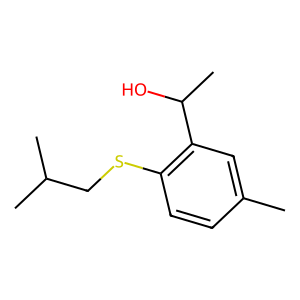

In [3]:
mol = Chem.MolFromInchi(inchi)
Draw.MolToImage(mol)

In [ ]:
AllChem.Compute2DCoords(mol) # meant to help drawing or something, might have to do this each time.
# looks the same though ha
Draw.MolToImage(mol)

How to write a drawing out as a file

In [4]:
drawer = Draw.rdMolDraw2D.MolDraw2DCairo(300,300)
opts = drawer.drawOptions()
opts.useBWAtomPalette()
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

with open('mol_drawing.png', 'wb') as f:
    f.write(drawer.GetDrawingText())



How to do inline images (nice for notebook), nice to set colours to black and white or colour

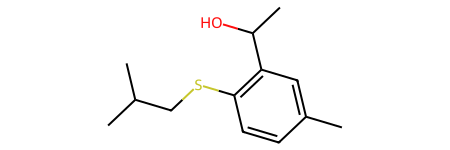

In [19]:
Draw.IPythonConsole.ipython_useSVG = True

Draw.IPythonConsole.drawOptions.useCDKAtomPalette()
mol

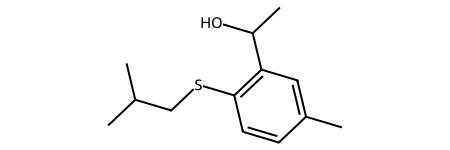

In [22]:
Draw.IPythonConsole.drawOptions.useBWAtomPalette()
mol

How to get coordinates of atoms

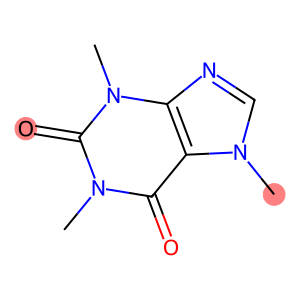

In [23]:
mol2 = Chem.MolFromSmiles('CN1C=NC2=C1C(=O)N(C(=O)N2C)C')
Draw.MolToImage(mol2, highlightAtoms=[0,10])

How to get the conformer coords (0,0 is roughly - but not guaranteed - to tbe the centre)
You can see that the leftmost highlight has a negative X coord

In [24]:
AllChem.Compute2DCoords(mol2)
conf = mol2.GetConformer()

bond = mol2.GetBondWithIdx(0)
a1 = bond.GetBeginAtomIdx()
a2 = bond.GetEndAtomIdx()
print(a1, a2)

bond = mol2.GetBondWithIdx(10)
a3 = bond.GetBeginAtomIdx()
a4 = bond.GetEndAtomIdx()
print(a3,a4)

pos1 = conf.GetAtomPosition(a1)
pos2 = conf.GetAtomPosition(a2)
print(pos1.x, pos1.y)

pos3 = conf.GetAtomPosition(a3)
pos4 = conf.GetAtomPosition(a4)
print(pos3.x, pos4.y)

0 1
9 11
3.378904996633575 -1.3434049403280268
-2.018151721250353 1.4013366110965497


We want the pixel positions in the image, so that we can crop them

274.1673355548494 194.44905239863704 red
25.8326644451506 128.51636762897252 green
113.58397332799247 95.33950501448868 blue


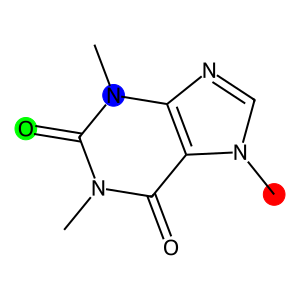

In [71]:
drawer = Draw.rdMolDraw2D.MolDraw2DCairo(300,300)  # note you might need to use PNG and IPython.display.Image  then (Image(drawer.Get...))
#drawer = Draw.rdMolDraw2D.MolDraw2DSVG(300,300)
opts = drawer.drawOptions()
opts.useBWAtomPalette()
drawer.DrawMolecule(mol2, 
                    highlightAtoms=[0,10,11],
                   highlightAtomColors={0:(1,0,0), 10:(0,1,0), 11:(0,0,1)})



drawer.FinishDrawing()

pt1 =drawer.GetDrawCoords(0)
pt2 = drawer.GetDrawCoords(10)
pt3 =drawer.GetDrawCoords(11)

print(pt1)


print(pt1.x, pt1.y, "red")
print(pt2.x, pt2.y, "green")
print(pt3.x, pt3.y, "blue")

Image(drawer.GetDrawingText())
#SVG(drawer.GetDrawingText())

From the above we can see that the x,y values correspond to displacement (in pixels? / units relative to the image size) from the *top left* of the image
```
SVG
274.1673355548494 194.44905239863704 red
25.8326644451506 128.51636762897252 green
113.58397332799247 95.33950501448868 blue

Image / png
274.1673355548494 194.44905239863704 red
25.8326644451506 128.51636762897252 green
113.58397332799247 95.33950501448868 blue
```

This will help us when we want to be able to crop and save an image for our training set